<a href="https://colab.research.google.com/github/siddhartha-sai-17/Machine_Learning/blob/main/FeatureToTargetAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = sns.load_dataset("taxis")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [ ]:
df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


In [ ]:
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='object')

In [ ]:
df.describe(include=object)

,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
count,6433,6389,6407,6388,6407,6388
unique,2,2,194,203,4,5
top,yellow,credit card,Midtown Center,Upper East Side North,Manhattan,Manhattan
freq,5451,4577,230,245,5268,5206


In [ ]:
df.shape

(6433, 14)

In [ ]:
df.isna().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [ ]:
(df.isna().sum()/df.shape[0])*100

,0
pickup,0.000000
dropoff,0.000000
passengers,0.000000
distance,0.000000
fare,0.000000
tip,0.000000
tolls,0.000000
total,0.000000
color,0.000000
payment,0.683973


In [ ]:
((df.shape[0] - df.dropna().shape[0])/df.shape[0])*100

1.4301259132597544

In [ ]:
df.dropna()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [ ]:
df = df.dropna()

In [ ]:
df=df.reset_index(drop=True)

In [ ]:
df.shape

(6341, 14)

In [ ]:
df.describe(include='object')

,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
count,6341,6341,6341,6341,6341,6341
unique,2,2,194,203,4,5
top,yellow,credit card,Midtown Center,Upper East Side North,Manhattan,Manhattan
freq,5373,4546,227,244,5226,5172


In [ ]:
#EDA

In [ ]:
# Tip is the target column

In [ ]:
# Tip is a numerical feature , but we need to analyse the color which is a categorical data

In [ ]:
df.color.value_counts()

,count
color,
yellow,5373
green,968


In [ ]:
# Graphical Analysis of categorical

<Axes: xlabel='color', ylabel='tip'>

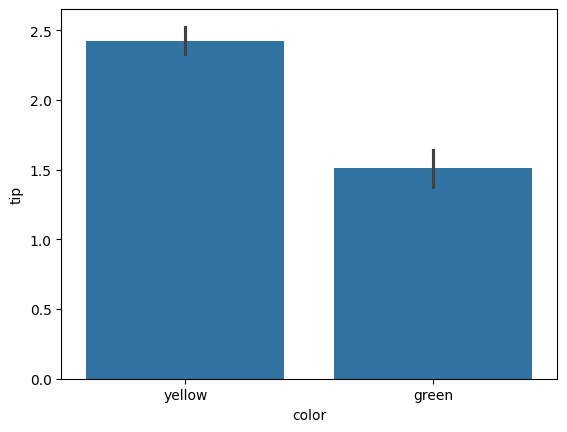

In [ ]:
sns.barplot(x=df.color,y=df.tip,estimator='std')

<Axes: xlabel='color', ylabel='tip'>

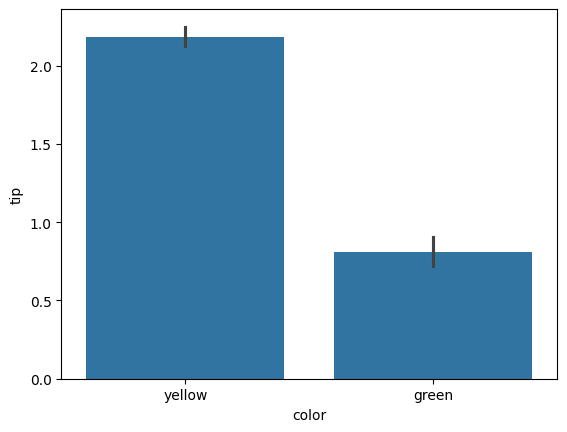

In [ ]:
sns.barplot(x=df.color,y=df.tip,estimator='mean')

<Axes: xlabel='tip', ylabel='Count'>

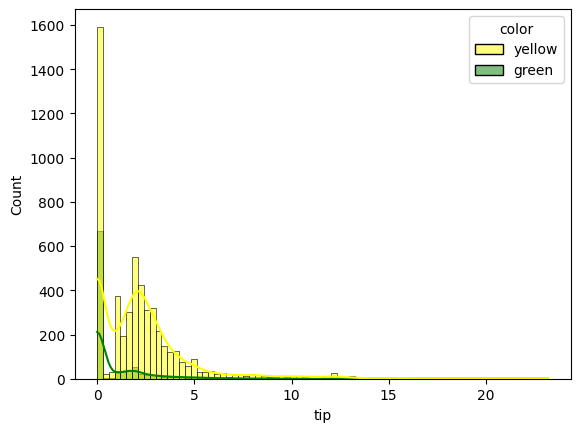

In [ ]:
sns.histplot(x=df.tip,hue=df.color,kde=True,palette={'yellow':'yellow','green':'green'})

In [17]:
green_tip = df["tip"].loc[df["color"] == "green"]
yellow_tip = df["tip"].loc[df["color"] == "yellow"]

In [18]:
green_tip,yellow_tip

(5373    0.00
 5374    0.00
 5375    1.20
 5376    0.00
 5377    0.00
         ... 
 6336    1.06
 6337    0.00
 6338    0.00
 6339    0.00
 6340    3.36
 Name: tip, Length: 968, dtype: float64,
 0       2.15
 1       0.00
 2       2.36
 3       6.15
 4       1.10
         ... 
 5368    2.66
 5369    2.36
 5370    2.56
 5371    2.36
 5372    1.33
 Name: tip, Length: 5373, dtype: float64)

In [19]:
from scipy import stats
t_stat,p_val =stats.ttest_ind(green_tip,yellow_tip)
print("Independent T- test Statistic",t_stat)
print("P-value",p_val)

Independent T- test Statistic -17.05932566128597
P-value 7.791088119489451e-64


In [20]:
if p_val<0.05:
    print("Reject Null Hypothesis")
else:
    print("Accept Null Hypothesis")

Reject Null Hypothesis


Based on the graphs the conclusion that tip will be

-> yellow taxis tip receievs the higher tip than the green tip taxis based on the mean tip
-> the greater variability in tips for the yellow taxis as the graph is more spread out than the other graph ->Yellow taxis have higher tip values and have longer tail
->Green tips have lower tip values

In [14]:
df.payment.value_counts()

,count
payment,
credit card,4546
cash,1795


<Axes: xlabel='payment', ylabel='tip'>

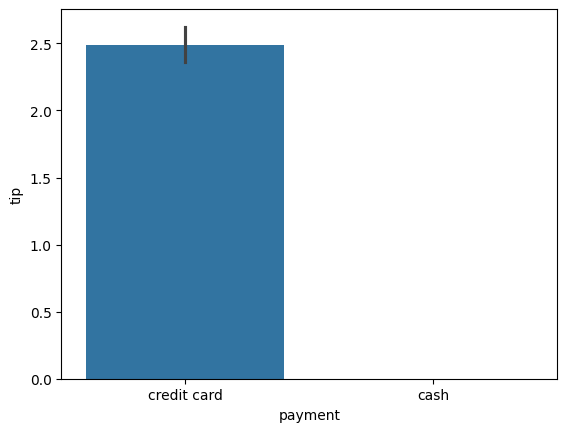

In [10]:
sns.barplot(x=df.payment,y=df.tip,estimator='std')

<Axes: xlabel='payment', ylabel='tip'>

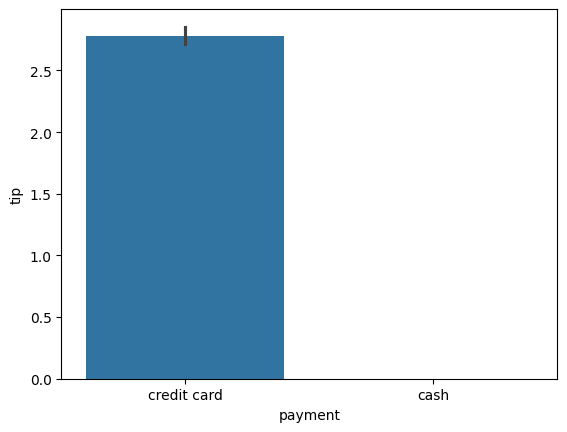

In [11]:
sns.barplot(x=df.payment,y=df.tip,estimator='mean')

<Axes: xlabel='tip', ylabel='Count'>

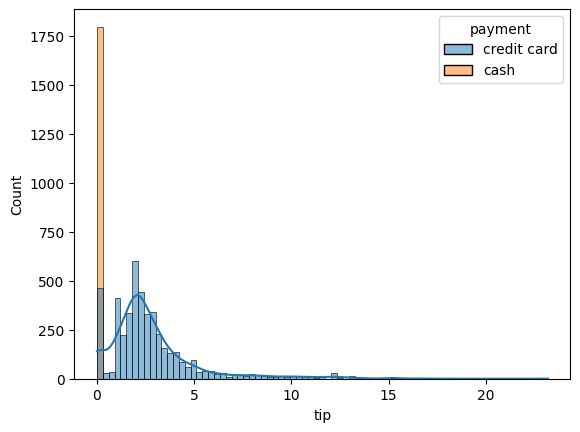

In [15]:
sns.histplot(x=df.tip,hue=df.payment,kde=True)

In [16]:
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6336,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6337,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6338,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6339,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [21]:
C_tip = df["tip"].loc[df["payment"] == "credit card"]
Cash_tip = df["tip"].loc[df["payment"] == "cash"]

In [24]:
from scipy import stats
t_stat,p_val =stats.ttest_ind(C_tip,Cash_tip)
print("Independent T- test Statistic",t_stat)
print("P-value",p_val)

Independent T- test Statistic 49.09538452722153
P-value 0.0


In [25]:
if p_val<0.05:
    print("Reject Null Hypothesis")
else:
    print("Accept Null Hypothesis")

Reject Null Hypothesis


In [ ]:
#There is effect of color on tip colmn

In [ ]:
#color payment

In [26]:
df['pickup_borough'].unique()

array(['Manhattan', 'Queens', 'Bronx', 'Brooklyn'], dtype=object)

In [27]:
df['pickup_borough'].value_counts()

,count
pickup_borough,
Manhattan,5226
Queens,638
Brooklyn,378
Bronx,99


/tmp/ipython-input-2881219962.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['pickup_borough'],palette='rainbow')


<Axes: xlabel='pickup_borough', ylabel='count'>

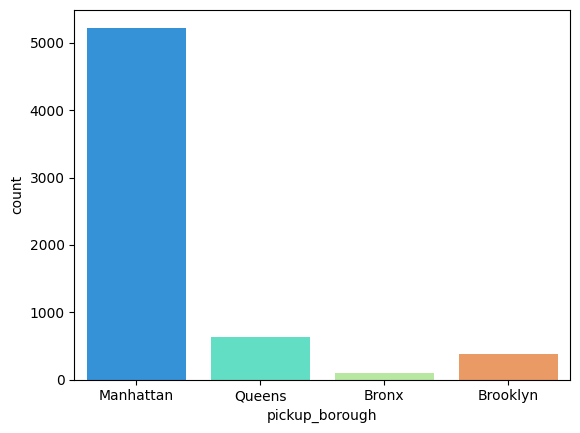

In [46]:
sns.countplot(x=df['pickup_borough'],palette='rainbow')

/tmp/ipython-input-854745851.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['pickup_borough'],y=df["tip"],palette='rainbow')


<Axes: xlabel='pickup_borough', ylabel='tip'>

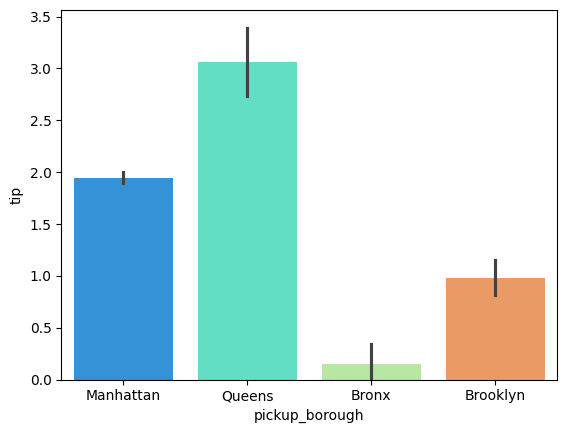

In [39]:
sns.barplot(x=df['pickup_borough'],y=df["tip"],palette='rainbow')

In [40]:
df['tip'].groupby(df['pickup_borough']).std()

,tip
pickup_borough,
Bronx,0.897261
Brooklyn,1.674487
Manhattan,1.997736
Queens,4.323951


<Axes: xlabel='tip', ylabel='Count'>

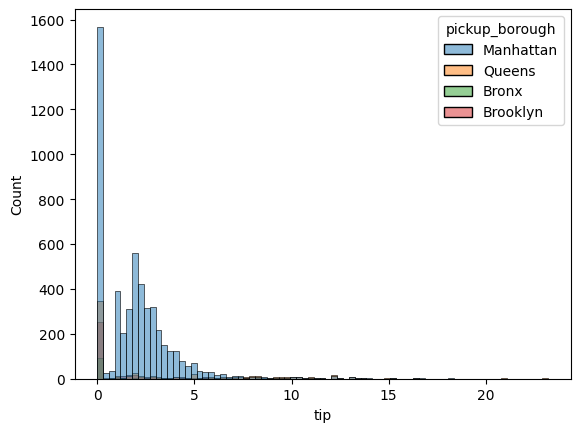

In [42]:
sns.histplot(hue=df['pickup_borough'],x=df['tip'])

Hypotheses:

H0:distribution tip is the same across all picku_borough categories

H1: At least one category has a different distribution of tip

In [48]:
manhattan_tip = df['tip'][df['pickup_borough']=='Manhattan']
queens_tip = df['tip'][df['pickup_borough']=='Queens']
brooklyn_tip = df['tip'][df['pickup_borough']=='Brooklyn']
bronx_tip = df['tip'][df['pickup_borough']=='Bronx']

In [49]:
# ANOVA Test
#regions = [group['Spending_Score'].values for name, group in data.groupby('Region')]
f_stat, p_val = stats.f_oneway(manhattan_tip ,queens_tip,brooklyn_tip,bronx_tip)
print("ANOVA F-statistic:", f_stat)
print("P-value:", p_val)

if p_val < 0.05:
    print("Reject null hypothesis: Spending Score differs by Region")
else:
    print("Fail to reject null hypothesis: No significant difference by Region")



ANOVA F-statistic: 91.57933831850573
P-value: 5.155109332422435e-58
Reject null hypothesis: Spending Score differs by Region


Hypotheses for Tukey test (for each pair of groups):

H0: distirbution of group1 = Mean distribution of group2

H1: distribution of group1 ≠ Mean Mean of group2

In [50]:
# Tukey HSD Test
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD
tukey_result = pairwise_tukeyhsd(endog=df.tip, groups=df.pickup_borough, alpha=0.05)
print(tukey_result)


  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
  group1    group2  meandiff p-adj lower  upper  reject
-------------------------------------------------------
    Bronx  Brooklyn   0.8305 0.008 0.1595 1.5015   True
    Bronx Manhattan    1.797   0.0  1.194    2.4   True
    Bronx    Queens   2.9179   0.0 2.2759 3.5599   True
 Brooklyn Manhattan   0.9665   0.0 0.6499  1.283   True
 Brooklyn    Queens   2.0873   0.0 1.7016 2.4731   True
Manhattan    Queens   1.1209   0.0 0.8716 1.3701   True
-------------------------------------------------------


In [51]:
df['dropoff_borough'].value_counts()

,count
dropoff_borough,
Manhattan,5172
Queens,534
Brooklyn,497
Bronx,136
Staten Island,2


/tmp/ipython-input-2461060733.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['dropoff_borough'],palette='rainbow')


<Axes: xlabel='dropoff_borough', ylabel='count'>

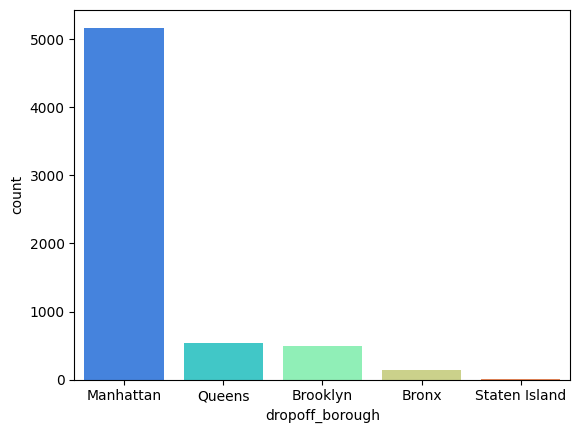

In [52]:
sns.countplot(x=df['dropoff_borough'],palette='rainbow')

/tmp/ipython-input-4217190562.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['dropoff_borough'],y=df['tip'],palette='rainbow')


<Axes: xlabel='dropoff_borough', ylabel='tip'>

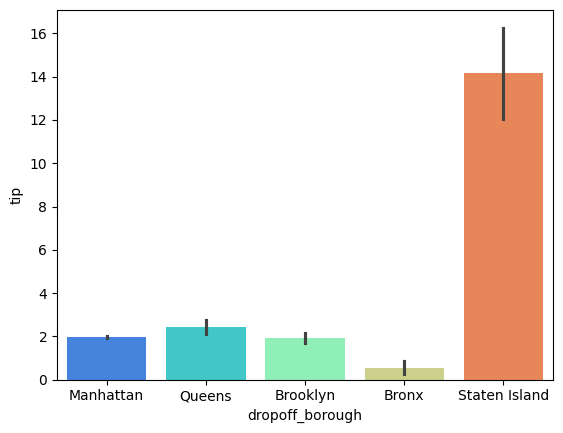

In [56]:
sns.barplot(x=df['dropoff_borough'],y=df['tip'],palette='rainbow')

In [60]:
df['tip'].groupby(df['dropoff_borough']).std()

,tip
dropoff_borough,
Bronx,1.788795
Brooklyn,2.896229
Manhattan,2.052074
Queens,3.947016
Staten Island,2.976920


<Axes: xlabel='tip', ylabel='Count'>

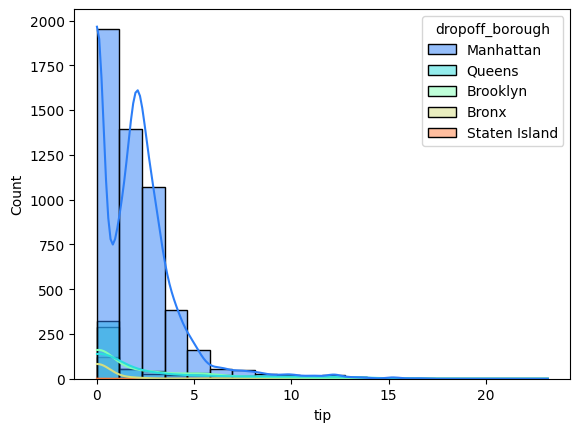

In [63]:
sns.histplot(hue=df['dropoff_borough'],x=df['tip'],kde=True,palette='rainbow',bins=20)

In [72]:
man_tip = df['tip'][df['dropoff_borough']=='Manhattan']
qu_tip = df['tip'][df['dropoff_borough']=='Queens']
broo_tip = df['tip'][df['dropoff_borough']=='Brooklyn']
bro_tip = df['tip'][df['dropoff_borough']=='Bronx']
st_tip = df['tip'][df['dropoff_borough']=='Staten Island']

In [73]:
# ANOVA Test
#regions = [group['Spending_Score'].values for name, group in data.groupby('Region')]
f_stat, p_val = stats.f_oneway(man_tip ,qu_tip,broo_tip,bro_tip,st_tip)
print("ANOVA F-statistic:", f_stat)
print("P-value:", p_val)

if p_val < 0.05:
    print("Reject null hypothesis: Spending Score differs by Region")
else:
    print("Fail to reject null hypothesis: No significant difference by Region")



ANOVA F-statistic: 31.424177966968298
P-value: 5.87859571331583e-26
Reject null hypothesis: Spending Score differs by Region


In [70]:
# Tukey HSD Test
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD
tukey_result = pairwise_tukeyhsd(endog=df.tip, groups=df.dropoff_borough, alpha=0.05)
print(tukey_result)


     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1      group2    meandiff p-adj   lower   upper  reject
--------------------------------------------------------------
    Bronx      Brooklyn   1.3869    0.0  0.7691  2.0046   True
    Bronx     Manhattan   1.4296    0.0  0.8751  1.9842   True
    Bronx        Queens   1.8873    0.0  1.2742  2.5005   True
    Bronx Staten Island  13.6303    0.0  9.0833 18.1773   True
 Brooklyn     Manhattan   0.0427 0.9952 -0.2571  0.3425  False
 Brooklyn        Queens   0.5004 0.0055  0.1026  0.8983   True
 Brooklyn Staten Island  12.2434    0.0  7.7204 16.7664   True
Manhattan        Queens   0.4577 0.0002  0.1675  0.7479   True
Manhattan Staten Island  12.2007    0.0  7.6859 16.7154   True
   Queens Staten Island   11.743    0.0  7.2206 16.2653   True
--------------------------------------------------------------


In [74]:
df


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6336,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6337,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6338,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6339,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [75]:
df['dropoff_zone'].value_counts()

,count
dropoff_zone,
Upper East Side North,244
Murray Hill,217
Midtown Center,215
Midtown East,175
Upper East Side South,173
...,...
Queensboro Hill,1
Homecrest,1
Madison,1


In [76]:
df['pickup'].value_counts()

,count
pickup,
2019-03-06 14:40:57,2
2019-03-11 20:28:00,2
2019-03-01 23:48:39,2
2019-03-22 23:15:20,2
2019-03-26 08:02:40,2
...,...
2019-03-27 14:33:39,1
2019-03-06 21:43:06,1
2019-03-11 22:23:49,1


<Axes: xlabel='dropoff_zone', ylabel='count'>

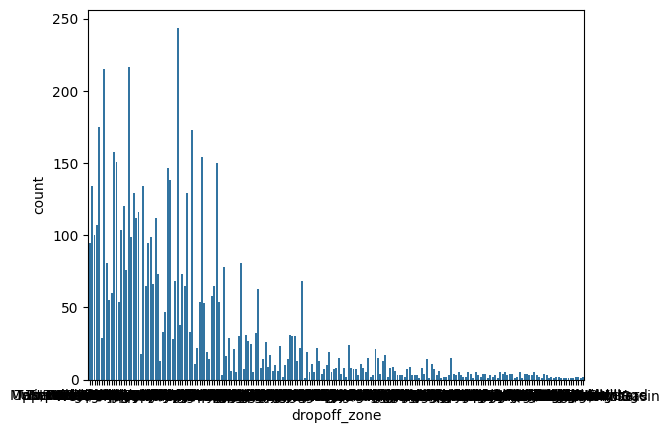

In [79]:
sns.countplot(x=df['dropoff_zone'])


In [81]:
# ANOVA Test
regions = [group['tip'].values for name, group in df.groupby('pickup_zone')]
f_stat, p_val = stats.f_oneway(*regions)
print("ANOVA F-statistic:", f_stat)
print("P-value:", p_val)

if p_val < 0.05:
    print("Reject null hypothesis: Spending Score differs by Region")
else:
    print("Fail to reject null hypothesis: No significant difference by Region")



ANOVA F-statistic: 7.563376210961916
P-value: 7.892434822136223e-169
Reject null hypothesis: Spending Score differs by Region


In [85]:
numer_cols =df.select_dtypes(include=['number']).columns
print(numer_cols)

Index(['passengers', 'distance', 'fare', 'tip', 'tolls', 'total'], dtype='object')


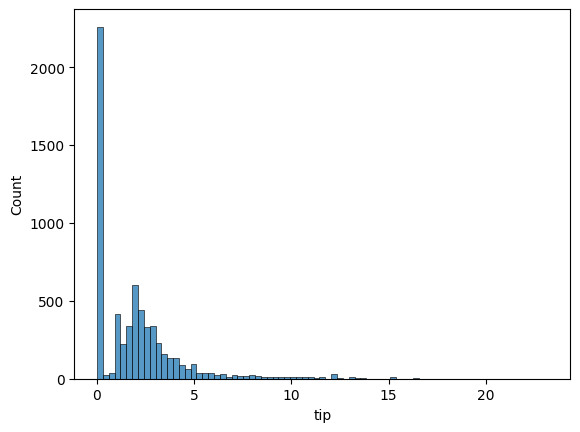

In [86]:
sns.histplot(df['tip'])
plt.show()

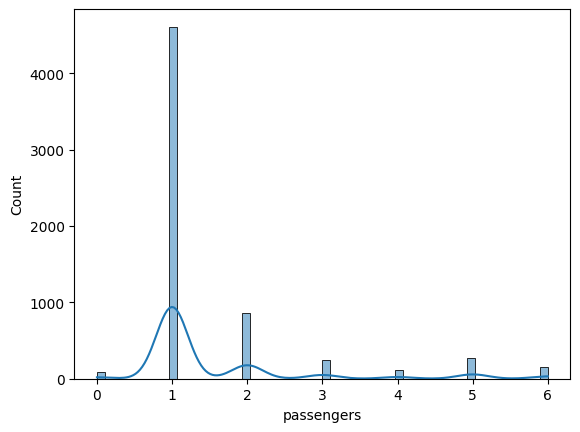

In [88]:
sns.histplot(df['passengers'],kde=True)
plt.show()

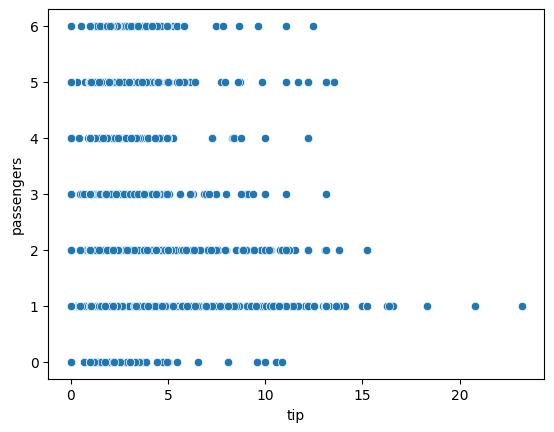

In [90]:
sns.scatterplot(x=df['tip'],y=df['passengers'])
plt.show()

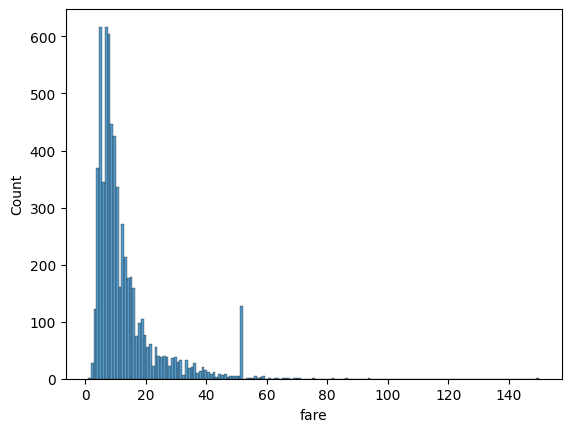

In [93]:
sns.histplot(df['fare'])
plt.show()

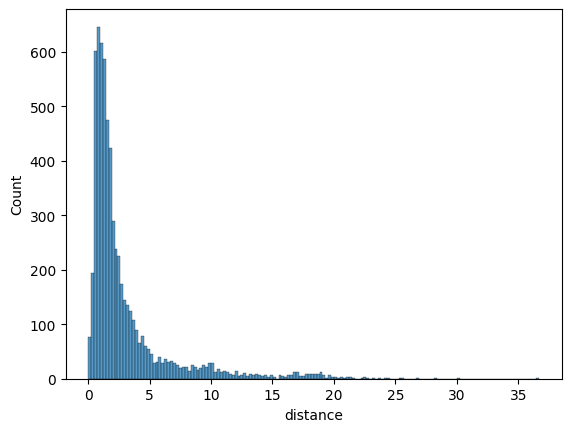

In [94]:
sns.histplot(df['distance'])
plt.show()

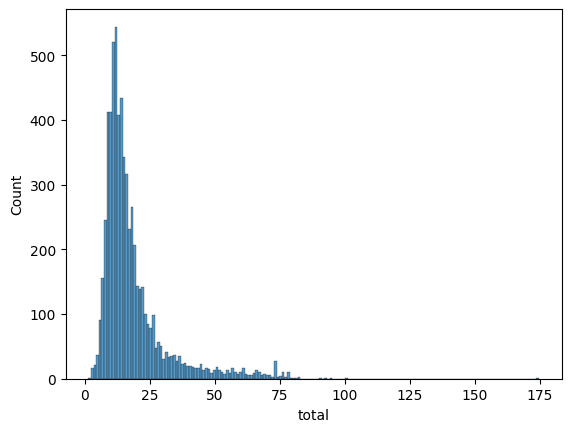

In [95]:
sns.histplot(df['total'])
plt.show()

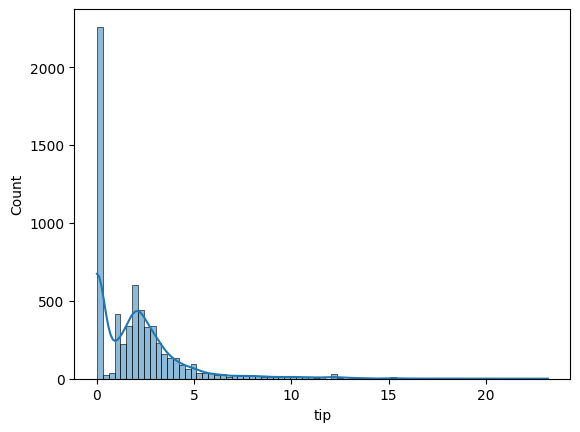

In [96]:
sns.histplot(df['tip'],kde=True)
plt.show()

In [97]:
r,p_val =stats.pearsonr(df['tip'],df['fare'])
print("Correlation Coefficient",r)
print("P-value",p_val)
alpha = 0.05
if p_val<alpha:
    print("Reject Null Hypothesis")
else:
    print("Accept Null Hypothesis")

Correlation Coefficient 0.48710089077355956
P-value 0.0
Reject Null Hypothesis


In [91]:
r,p_val =stats.pearsonr(df['tip'],df['passengers'])
print("Correlation Coefficient",r)
print("P-value",p_val)
alpha = 0.05
if p_val<alpha:
    print("Reject Null Hypothesis")
else:
    print("Accept Null Hypothesis")

Correlation Coefficient 0.017838280361313713
P-value 0.15551969503298518
Accept Null Hypothesis


In [98]:
r,p_val =stats.spearmanr(df['tip'],df['passengers'])
print("Correlation Coefficient",r)
print("P-value",p_val)
alpha = 0.05
if p_val<alpha:
    print("Reject Null Hypothesis")
else:
    print("Accept Null Hypothesis")

Correlation Coefficient 0.027509812818779178
P-value 0.028480753176042872
Reject Null Hypothesis


In [92]:
r,p_val =stats.spearmanr(df['tip'],df['passengers'])
print("Correlation Coefficient",r)
print("P-value",p_val)
alpha = 0.05
if p_val<alpha:
    print("Reject Null Hypothesis")
else:
    print("Accept Null Hypothesis")

Correlation Coefficient 0.027509812818779178
P-value 0.028480753176042872
Reject Null Hypothesis


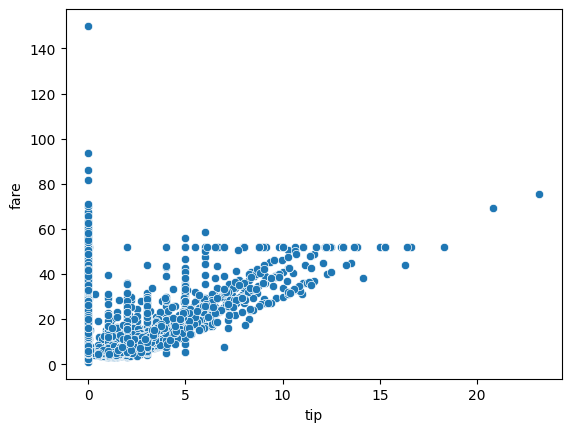

In [99]:
sns.scatterplot(x=df['tip'],y=df['fare'])
plt.show()

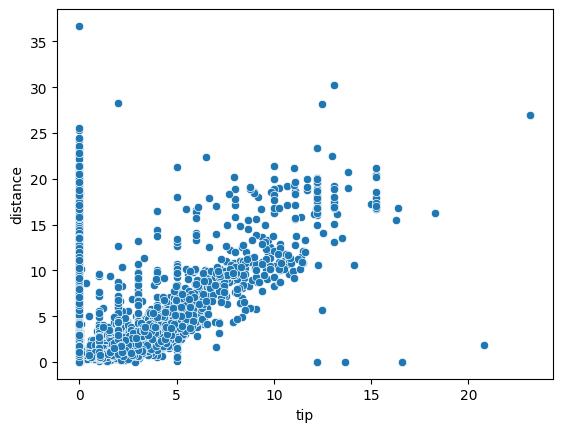

In [100]:
sns.scatterplot(x=df['tip'],y=df['distance'])
plt.show()

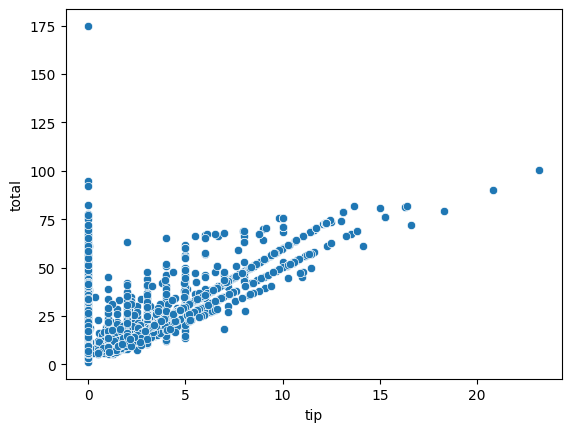

In [103]:
sns.scatterplot(x=df['tip'],y=df['total'])
plt.show()

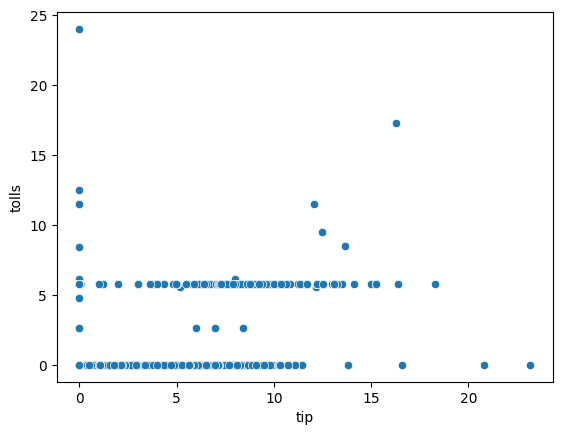

In [104]:
sns.scatterplot(x=df['tip'],y=df['tolls'])
plt.show()

In [105]:
r,p_val =stats.pearsonr(df['tip'],df['tolls'])
print("Correlation Coefficient",r)
print("P-value",p_val)
alpha = 0.05
if p_val<alpha:
    print("Reject Null Hypothesis")
else:
    print("Accept Null Hypothesis")

Correlation Coefficient 0.41467000187389874
P-value 4.5828986386065086e-262
Reject Null Hypothesis


In [106]:
r,p_val =stats.pearsonr(df['tip'],df['distance'])
print("Correlation Coefficient",r)
print("P-value",p_val)
alpha = 0.05
if p_val<alpha:
    print("Reject Null Hypothesis")
else:
    print("Accept Null Hypothesis")

Correlation Coefficient 0.4769796821455606
P-value 0.0
Reject Null Hypothesis


In [107]:
r,p_val =stats.pearsonr(df['tip'],df['total'])
print("Correlation Coefficient",r)
print("P-value",p_val)
alpha = 0.05
if p_val<alpha:
    print("Reject Null Hypothesis")
else:
    print("Accept Null Hypothesis")

Correlation Coefficient 0.6506766365313064
P-value 0.0
Reject Null Hypothesis


In [110]:
nm = df[['fare','tip','tolls','distance','total']]

<Axes: >

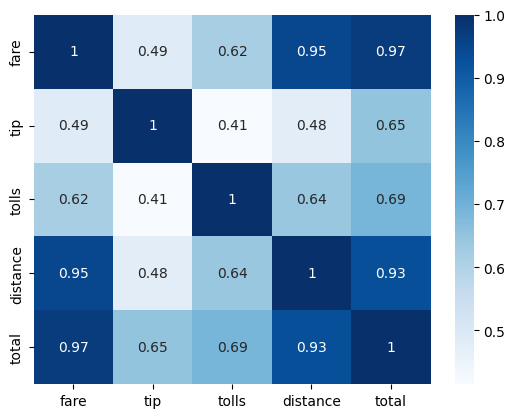

In [117]:
sns.heatmap(nm.corr(),annot=True,cmap='Blues')